**Table of contents**<a id='toc0_'></a>    
- 1. [Problem 1: Production economy and CO2 taxation](#toc1_)    
- 2. [Problem 2: Career choice model](#toc2_)    
- 3. [Problem 3: Barycentric interpolation](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [20]:
# Write your code here
import numpy as np
from types import SimpleNamespace
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fsolve, minimize_scalar, minimize

## 1. <a id='toc1_'></a>[Problem 1: Production economy and CO2 taxation](#toc0_)

Consider a production economy with two firms indexed by $j \in \{1,2\}$. Each produce its own good. They solve

$$
\begin{align*}
\max_{y_{j}}\pi_{j}&=p_{j}y_{j}-w_{j}\ell_{j}\\\text{s.t.}\;&y_{j}=A\ell_{j}^{\gamma}.
\end{align*}
$$

Optimal firm behavior is

$$
\begin{align*}
\ell_{j}^{\star}(w,p_{j})&=\left(\frac{p_{j}A\gamma}{w}\right)^{\frac{1}{1-\gamma}} \\
y_{j}^{\star}(w,p_{j})&=A\left(\ell_{j}^{\star}(w,p_{j})\right)^{\gamma}
\end{align*}
$$

The implied profits are

$$
\pi_{j}^*(w,p_{j})=\frac{1-\gamma}{\gamma}w\cdot\left(\frac{p_{j}A\gamma}{w}\right)^{\frac{1}{1-\gamma}}
$$

A single consumer supplies labor, and consumes the goods the firms produce. She also recieves the implied profits of the firm.<br>
She solves:

$$
\begin{align*}
U(p_1,p_2,w,\tau,T) = \max_{c_{1},c_{2},\ell} & \log(c_{1}^{\alpha}c_{2}^{1-\alpha})-\nu\frac{\ell^{1+\epsilon}}{1+\epsilon} \\
\text{s.t.}\,\,\,&p_{1}c_{1}+(p_{2}+\tau)c_{2}=w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})
\end{align*}
$$

where $\tau$ is a tax and $T$ is lump-sum transfer. <br>
For a given $\ell$, it can be shown that optimal behavior is

$$
\begin{align*}
c_{1}(\ell)&=\alpha\frac{w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})}{p_{1}} \\
c_{2}(\ell)&=(1-\alpha)\frac{w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})}{p_{2}+\tau} \\
\end{align*}
$$
Such that optimal behavior is:
$$
\ell^* = \underset{\ell}{\arg\max} \log(\left(c_{1}(\ell)\right)^{\alpha}\cdot \left(c_{2}(\ell)\right)^{1-\alpha})-\nu\frac{\ell^{1+\epsilon}}{1+\epsilon} 
$$
With optimal consumption:
$$
\begin{align*}
c_1^*=c_{1}(\ell^*) \\
c_2^*=c_{2}(\ell^*)\\
\end{align*}
$$


The government chooses $\tau$ and balances its budget so $T=\tau c_2^*$. We initially set $\tau,T=0$.

Market clearing requires:

1. Labor market: $\ell^* = \ell_1^* + \ell_2^*$
1. Good market 1: $c_1^* = y_1^*$
1. Good market 2: $c_2^* = y_2^*$


**Question 1:** Check market clearing conditions for $p_1$ in `linspace(0.1,2.0,10)` and $p_2$ in `linspace(0.1,2.0,10)`. We choose $w=1$ as numeraire.

In [21]:
par = SimpleNamespace()

# firms
par.A = 1.0
par.gamma = 0.5

# households
par.alpha = 0.3
par.nu = 1.0
par.epsilon = 2.0

# government
par.tau = 0.0
par.T = 0.0

# Question 3
par.kappa = 0.1

In [22]:
# Defining the functions: 

def optimal_labor(w, p, A, gamma):
    return (p * A * gamma / w) ** (1 / (1 - gamma))

def optimal_production(w, p, A, gamma):
    ell_star = optimal_labor(w, p, A, gamma)
    return A * ell_star ** gamma

def implied_profits(w, p, A, gamma):
    ell_star = optimal_labor(w, p, A, gamma)
    return (1 - gamma) / gamma * w * ell_star

def optimal_consumption(w, p1, p2, T, tau, pi1, pi2, alpha):
    income = w + T + pi1 + pi2
    c1 = alpha * income / p1
    c2 = (1 - alpha) * income / (p2 + tau)
    return c1, c2

def optimal_labor_supply(p1, p2, w, T, tau, alpha, nu, epsilon, A, gamma):
    pi1 = implied_profits(w, p1, A, gamma)
    pi2 = implied_profits(w, p2, A, gamma)
    def utility_maximization(ell):
        c1, c2 = optimal_consumption(w * ell, p1, p2, T, tau, pi1, pi2, alpha)
        utility = np.log(c1**alpha * c2**(1 - alpha)) - nu * ell**(1 + epsilon) / (1 + epsilon)
        return utility
    result = minimize_scalar(lambda ell: -utility_maximization(ell), bounds=(0, 100), method='bounded')
    return result.x

# Checking market clearing

def check_market_clearing(p1, p2, w, A, gamma, alpha, nu, epsilon, tau, T):
    ell_star = optimal_labor_supply(p1, p2, w, T, tau, alpha, nu, epsilon, A, gamma)
    c1_star, c2_star = optimal_consumption(w * ell_star, p1, p2, T, tau, implied_profits(w, p1, A, gamma), implied_profits(w, p2, A, gamma), alpha)
    y1_star = optimal_production(w, p1, A, gamma)
    y2_star = optimal_production(w, p2, A, gamma)
    ell1_star = optimal_labor(w, p1, A, gamma)
    ell2_star = optimal_labor(w, p2, A, gamma)
    labor_market_clearing = np.isclose(ell_star, ell1_star + ell2_star)
    good_market_1_clearing = np.isclose(c1_star, y1_star)
    good_market_2_clearing = np.isclose(c2_star, y2_star)
    return labor_market_clearing, good_market_1_clearing, good_market_2_clearing

# We have given the linspace, and we define the p values as these

p1_values = np.linspace(0.1, 2.0, 10)
p2_values = np.linspace(0.1, 2.0, 10)

# Checking the market clearing conditions for each pair of prices
results = []
for p1 in p1_values:
    for p2 in p2_values:
        labor_market, good_market_1, good_market_2 = check_market_clearing(p1, p2, 1.0, par.A, par.gamma, par.alpha, par.nu, par.epsilon, par.tau, par.T)
        results.append((p1, p2, labor_market, good_market_1, good_market_2))


df = pd.DataFrame(results, columns=['p1', 'p2', 'Labor Market Clearing', 'Good Market 1 Clearing', 'Good Market 2 Clearing'])

# We make a function that count the number of true values 

labor_market_counts = df['Labor Market Clearing'].value_counts()
good_market_1_counts = df['Good Market 1 Clearing'].value_counts()
good_market_2_counts = df['Good Market 2 Clearing'].value_counts()

def print_counts(label, counts):
    true_count = counts.get(True, 0)
    false_count = counts.get(False, 0)
    print(f"{label} - True: {true_count}, False: {false_count}")

print_counts("Labor Market Clearing", labor_market_counts)
print_counts("Good Market 1 Clearing", good_market_1_counts)
print_counts("Good Market 2 Clearing", good_market_2_counts)

Labor Market Clearing - True: 0, False: 100
Good Market 1 Clearing - True: 0, False: 100
Good Market 2 Clearing - True: 0, False: 100


We see that there are no values for $p_1$ and $p_2$ in the linspace that clears the market 

**Question 2:** Find the equilibrium prices $p_1$ and $p_2$.<br>
*Hint: you can use Walras' law to only check 2 of the market clearings*

In [23]:
def market_clearing_equations(prices, w, A, gamma, alpha, nu, epsilon, tau, T):
    p1, p2 = prices
    ell_star = optimal_labor_supply(p1, p2, w, T, tau, alpha, nu, epsilon, A, gamma)
    c1_star, c2_star = optimal_consumption(w * ell_star, p1, p2, T, tau, implied_profits(w, p1, A, gamma), implied_profits(w, p2, A, gamma), alpha)
    y1_star = optimal_production(w, p1, A, gamma)
    y2_star = optimal_production(w, p2, A, gamma)
    ell1_star = optimal_labor(w, p1, A, gamma)
    ell2_star = optimal_labor(w, p2, A, gamma)
    
    # Walras' law implies we need to check only two markets for equilibrium
    market1_clearing = c1_star - y1_star
    market2_clearing = c2_star - y2_star
    
    return [market1_clearing, market2_clearing]

initial_guess = [1.0, 1.0]

equilibrium_prices = fsolve(market_clearing_equations, initial_guess, args=(1.0, par.A, par.gamma, par.alpha, par.nu, par.epsilon, par.tau, par.T))

p1_eq, p2_eq = equilibrium_prices

print(f'Equilibrium prices: p1 = {p1_eq:.4f}, p2 = {p2_eq:.4f}')

Equilibrium prices: p1 = 0.9759, p2 = 1.4908


Assume the government care about the social welfare function:

$$
SWF = U - \kappa y_2^*
$$

Here $\kappa$ measures the social cost of carbon emitted by the production of $y_2$ in equilibrium.

**Question 3:** What values of $\tau$ and (implied) $T$ should the government choose to maximize $SWF$?

In [24]:
initial_tau = 0.1
def social_welfare(tau, w, A, gamma, alpha, nu, epsilon, kappa, p1, p2):
    def utility_with_tax(tau, w, A, gamma, alpha, nu, epsilon):
        # We calculate equilibrium with given tau
        T = tau * optimal_consumption(w, p1, p2, 0, tau, implied_profits(w, p1, A, gamma), implied_profits(w, p2, A, gamma), alpha)[1]
        ell_star = optimal_labor_supply(p1, p2, w, T, tau, alpha, nu, epsilon, A, gamma)
        c1_star, c2_star = optimal_consumption(w * ell_star, p1, p2, T, tau, implied_profits(w, p1, A, gamma), implied_profits(w, p2, A, gamma), alpha)
        y1_star = optimal_production(w, p1, A, gamma)
        y2_star = optimal_production(w, p2, A, gamma)
        U = np.log(c1_star**alpha * c2_star**(1 - alpha)) - nu * ell_star**(1 + epsilon) / (1 + epsilon)
        SWF = U - kappa * y2_star
        return SWF
    
    # We optimize the social welfare function with respect to tau
    def objective(tau):
        return -utility_with_tax(tau, w, A, gamma, alpha, nu, epsilon) 

    result = minimize(objective, initial_tau)
    optimal_tau = result.x[0]
    T = optimal_tau * optimal_consumption(w, p1, p2, 0, optimal_tau, implied_profits(w, p1, A, gamma), implied_profits(w, p2, A, gamma), alpha)[1]
    return optimal_tau, T


optimal_tau, optimal_T = social_welfare(initial_tau, 1.0, par.A, par.gamma, par.alpha, par.nu, par.epsilon, par.kappa, p1_eq, p2_eq)

print(f'Optimal tau: {optimal_tau:.4f}')
print(f'Optimal T: {optimal_T:.4f}')

Optimal tau: 0.1183
Optimal T: 0.0923


We find that values of $\tau$ and $T$ that maximizes SWF

## 2. <a id='toc2_'></a>[Problem 2: Career choice model](#toc0_)

Consider a graduate $i$ making a choice between entering $J$ different career tracks. <br>
Entering career $j$ yields utility $u^k_{ij}$. This value is unknown to the graduate ex ante, but will ex post be: <br>
$$
    u_{i,j}^k = v_{j} + \epsilon_{i,j}^k
$$

They know that $\epsilon^k_{i,j}\sim \mathcal{N}(0,\sigma^2)$, but they do not observe $\epsilon^k_{i,j}$ before making their career choice. <br>

Consider the concrete case of $J=3$ with:
$$
\begin{align*}
    v_{1} &= 1 \\
    v_{2} &= 2 \\
    v_{3} &= 3
\end{align*}
$$

If the graduates know the values of $v_j$ and the distribution of $\epsilon_{i,j}^k$, they can calculate the expected utility of each career track using simulation: <br>
$$
    \mathbb{E}\left[ u^k_{i,j}\vert v_j \right] \approx v_j + \frac{1}{K}\sum_{k=1}^K \epsilon_{i,j}^k
$$

In [25]:
par = SimpleNamespace()
par.J = 3
par.N = 10
par.K = 10000

par.F = np.arange(1,par.N+1)
par.sigma = 2

par.v = np.array([1,2,3])
par.c = 1

**Question 1:** Simulate and calculate expected utility and the average realised utility for $K=10000$ draws, for each career choice $j$.


In [26]:
expected_utility = np.zeros(par.J)
average_realized_utility = np.zeros(par.J)


for j in range(par.J):
    epsilon = np.random.normal(0, par.sigma, par.K)
    expected_utility[j] = par.v[j] + np.mean(epsilon)
    realized_utility = par.v[j] + epsilon
    average_realized_utility[j] = np.mean(realized_utility)

results = pd.DataFrame({
    'Career Choice (j)': np.arange(1, par.J + 1),
    'Expected Utility': expected_utility,
    'Average Realized Utility': average_realized_utility})

print(results)

   Career Choice (j)  Expected Utility  Average Realized Utility
0                  1          1.009583                  1.009583
1                  2          1.990337                  1.990337
2                  3          3.023520                  3.023520


Now consider a new scenario: Imagine that the graduate does not know $v_j$. The *only* prior information they have on the value of each job, comes from their $F_{i}$ friends that work in each career $j$. After talking with them, they know the average utility of their friends (which includes their friends' noise term), giving them the prior expecation: <br>
$$
\tilde{u}^k_{i,j}\left( F_{i}\right) = \frac{1}{F_{i}}\sum_{f=1}^{F_{i}} \left(v_{j} + \epsilon^k_{f,j}\right), \; \epsilon^k_{f,j}\sim \mathcal{N}(0,\sigma^2)
$$
For ease of notation consider that each graduate have $F_{i}=i$ friends in each career. <br>

For $K$ times do the following: <br>
1. For each person $i$ draw $J\cdot F_i$ values of $\epsilon_{f,j}^{k}$, and calculate the prior expected utility of each career track, $\tilde{u}^k_{i,j}\left( F_{i}\right)$. <br>
Also draw their own $J$ noise terms, $\epsilon_{i,j}^k$
1. Each person $i$ chooses the career track with the highest expected utility: $$j_i^{k*}= \arg\max_{j\in{1,2\dots,J}}\left\{ \tilde{u}^k_{i,j}\left( F_{i}\right)\right\} $$
1. Store the chosen careers: $j_i^{k*}$, the prior expectation of the value of their chosen career: $\tilde{u}^k_{i,j=j_i^{k*}}\left( F_{i}\right)$, and the realized value of their chosen career track: $u^k_{i,j=j_i^{k*}}=v_{j=j_i^{k*}}+\epsilon_{i,j=j_i^{k*}}^k$.

Chosen values will be: <br>
$i\in\left\{1,2\dots,N\right\}, N=10$ <br>
$F_i = i$<br>
So there are 10 graduates. The first has 1 friend in each career, the second has 2 friends, ... the tenth has 10 friends.

**Question 2:** Simulate and visualize: For each type of graduate, $i$, the share of graduates choosing each career, the average subjective expected utility of the graduates, and the average ex post realized utility given their choice. <br>
That is, calculate and visualize: <br>
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \mathbb{I}\left\{ j=j_i^{k*} \right\}  \;\forall j\in\left\{1,2,\dots,J\right\}
\end{align*}
$$
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \tilde{u}^k_{ij=j_i^{k*}}\left( F_{i}\right)
\end{align*}
$$
And 
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} u^k_{ij=j_i^{k*}} 
\end{align*}
$$
For each graduate $i$.

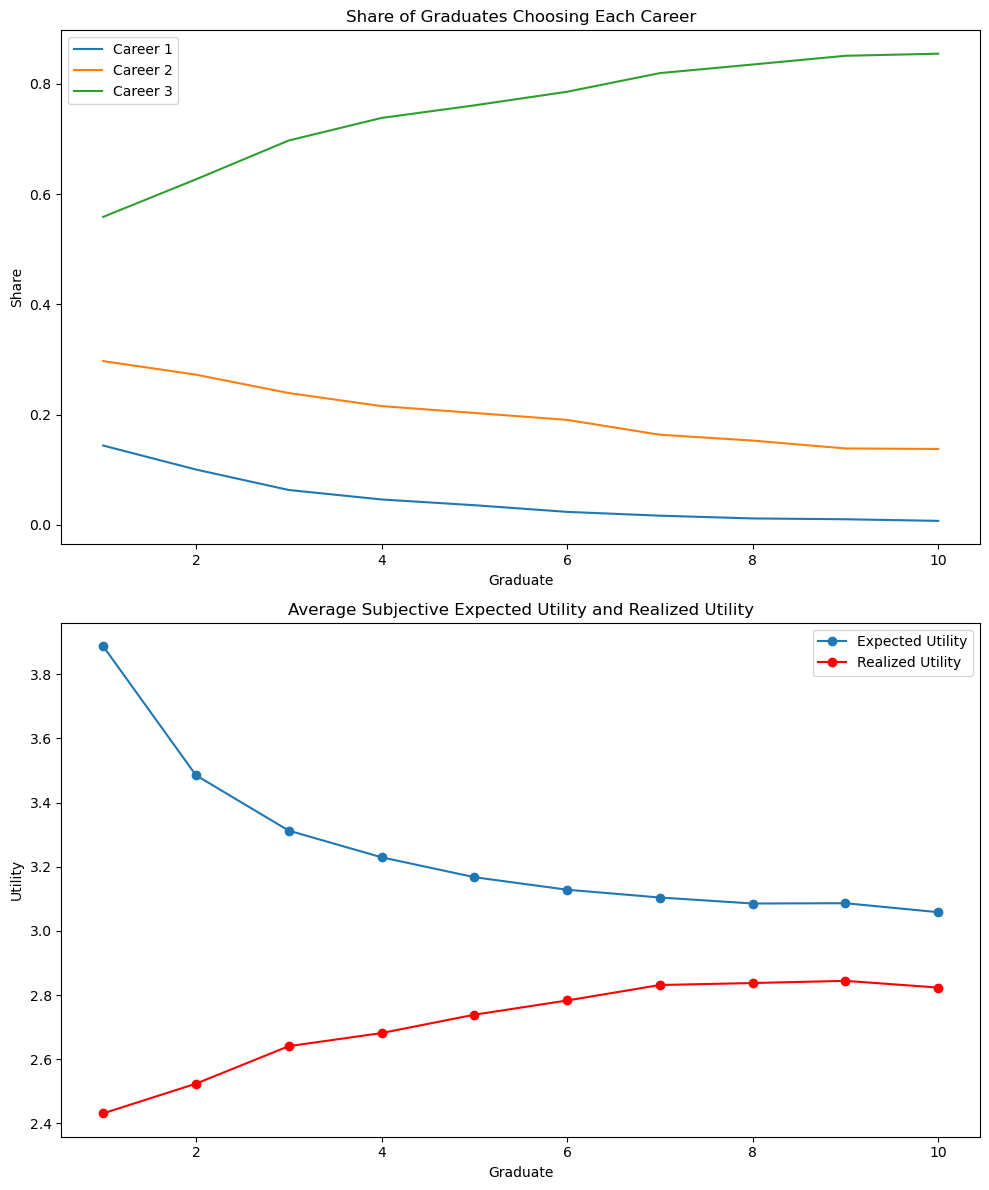

In [27]:
choices = np.zeros((par.N, par.J))
expected_utilities = np.zeros(par.N)
realized_utilities = np.zeros(par.N)

# Simulating the process for K iterations
for k in range(par.K):
    for i in range(par.N):
        Fi = par.F[i]
        prior_expected_utility = np.zeros(par.J)
        
        for j in range(par.J):
            epsilon_friends = np.random.normal(0, par.sigma, Fi)
            prior_expected_utility[j] = par.v[j] + np.mean(epsilon_friends)
        
        epsilon_individual = np.random.normal(0, par.sigma, par.J)
        
        chosen_career = np.argmax(prior_expected_utility)
        choices[i, chosen_career] += 1
        
        expected_utilities[i] += prior_expected_utility[chosen_career]
        realized_utilities[i] += par.v[chosen_career] + epsilon_individual[chosen_career]

choices /= par.K
expected_utilities /= par.K
realized_utilities /= par.K

# Preparing the data for visualization
results = pd.DataFrame({
    'Graduate': np.arange(1, par.N + 1),
    'Expected Utility': expected_utilities,
    'Realized Utility': realized_utilities,
})

for j in range(par.J):
    results[f'Share Choosing Career {j + 1}'] = choices[:, j]

fig, axs = plt.subplots(2, 1, figsize=(10, 12))

# We plot the share of graduates choosing each career, the average subjective expected utility and the average ex post realized utility
for j in range(par.J):
    axs[0].plot(results['Graduate'], results[f'Share Choosing Career {j + 1}'], label=f'Career {j + 1}')
axs[0].set_title('Share of Graduates Choosing Each Career')
axs[0].set_xlabel('Graduate')
axs[0].set_ylabel('Share')
axs[0].legend()

axs[1].plot(results['Graduate'], results['Expected Utility'], marker='o', label='Expected Utility')
axs[1].plot(results['Graduate'], results['Realized Utility'], marker='o', color='r', label='Realized Utility')
axs[1].set_title('Average Subjective Expected Utility and Realized Utility')
axs[1].set_xlabel('Graduate')
axs[1].set_ylabel('Utility')
axs[1].legend()

plt.tight_layout()
plt.show()

We see that as graduates get more friends and thus more information they are more likely to choose a better career.
When they have more friends they can better predict their expected utility thus leading this to fall. However as they are more likely to choose a better career their avereage realized utility increases

After a year of working in their career, the graduates learn $u^k_{ij}$ for their chosen job $j_i^{k*}$ perfectly. <br>
The can switch to one of the two remaining careers, for which they have the same prior as before, but it will now include a switching cost of $c$ which is known.
Their new priors can be written as: 
$$
\tilde{u}^{k,2}_{ij}\left( F_{i}\right) = \begin{cases}
            \tilde{u}^k_{ij}\left( F_{i}\right)-c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

We will set $c=1$.

Their realized utility will be: <br>
$$
u^{k,2}_{ij}= \begin{cases}
            u_{ij}^k -c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

**Question 3:** Following the same approach as in question 2, find the new optimal career choice for each $i$, $k$. Then for each $i$, calculate the average subjective expected utility from their new optimal career choice, and the ex post realized utility of that career. Also, for each $i$, calculate the share of graduates that chooses to switch careers, conditional on which career they chose in the first year. <br>

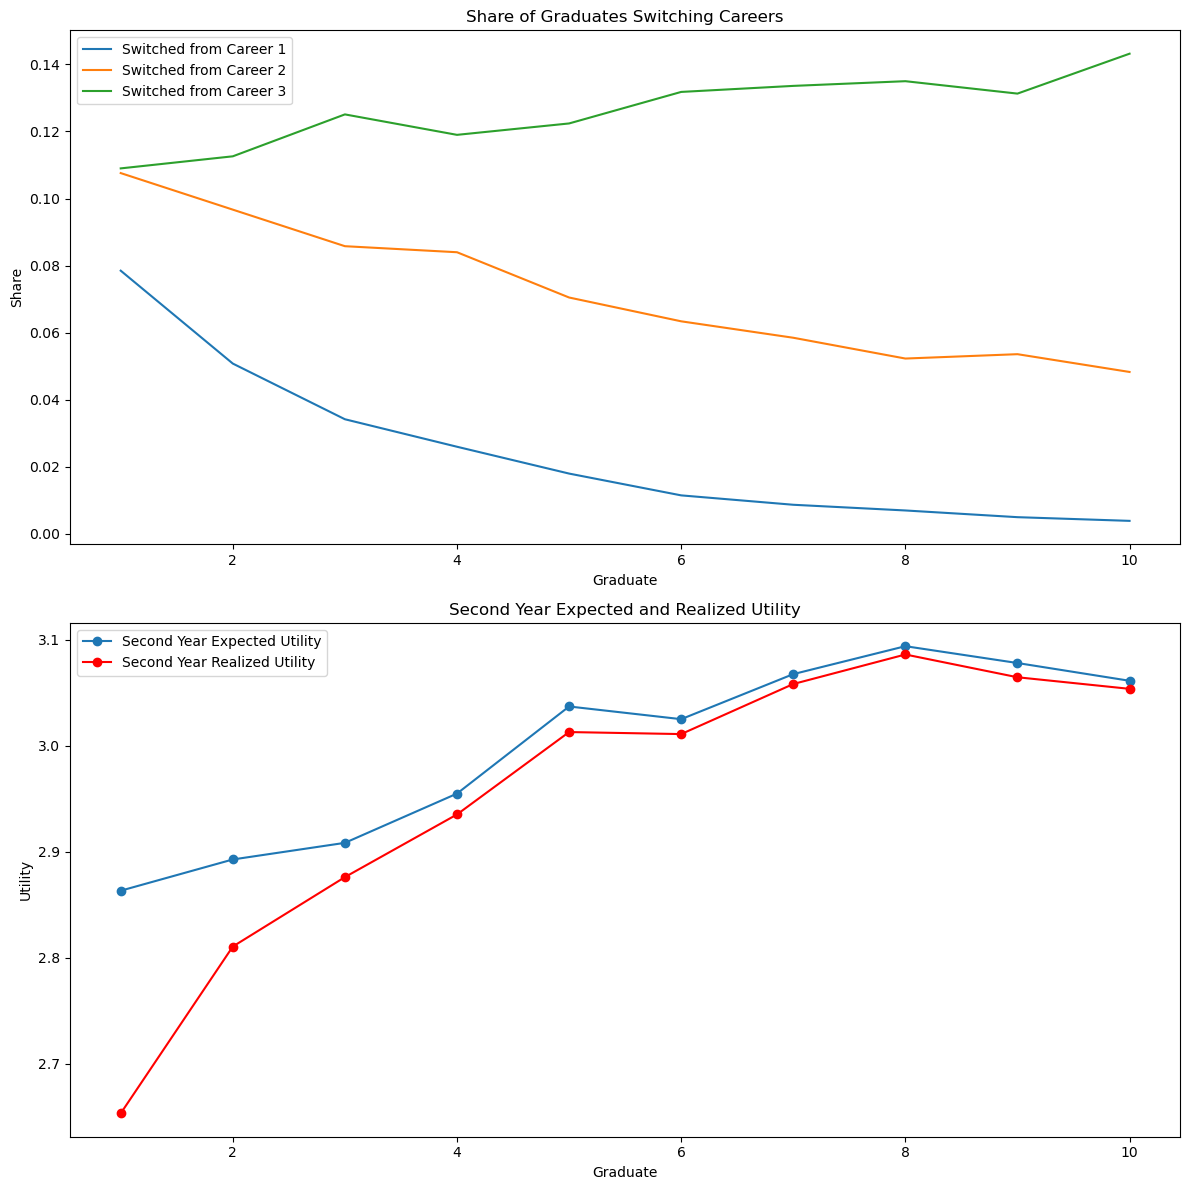

In [28]:
new_expected_utilities = np.zeros(par.N)
new_realized_utilities = np.zeros(par.N)
switching_shares = np.zeros((par.N, par.J))

# Simulating the process for K iterations
for k in range(par.K):
    first_year_choices = np.zeros(par.N, dtype=int)
    
    for i in range(par.N):
        Fi = par.F[i]
        prior_expected_utility = np.zeros(par.J)
        
        for j in range(par.J):
            epsilon_friends = np.random.normal(0, par.sigma, Fi)
            prior_expected_utility[j] = par.v[j] + np.mean(epsilon_friends)
        
        epsilon_individual = np.random.normal(0, par.sigma, par.J)
        
        chosen_career = np.argmax(prior_expected_utility)
        first_year_choices[i] = chosen_career
        choices[i, chosen_career] += 1
        
        expected_utilities[i] += prior_expected_utility[chosen_career]
        realized_utilities[i] += par.v[chosen_career] + epsilon_individual[chosen_career]
        
        new_prior_expected_utility = prior_expected_utility
        new_prior_expected_utility[chosen_career] = par.v[chosen_career] + epsilon_individual[chosen_career]
        for j in range(par.J):
            if j != chosen_career:
                new_prior_expected_utility[j] -= par.c
        
        new_chosen_career = np.argmax(new_prior_expected_utility)
        
        if new_chosen_career != chosen_career:
            switching_shares[i, chosen_career] += 1
        
        new_expected_utilities[i] += new_prior_expected_utility[new_chosen_career]
        if new_chosen_career == chosen_career:
            new_realized_utilities[i] += par.v[chosen_career] + epsilon_individual[chosen_career]
        else:
            new_realized_utilities[i] += par.v[new_chosen_career] + epsilon_individual[new_chosen_career] - par.c

# Calculating the averages
choices /= par.K
expected_utilities /= par.K
realized_utilities /= par.K
new_expected_utilities /= par.K
new_realized_utilities /= par.K
switching_shares /= par.K

# The share of graduates switching from each career
switching_shares_by_career = switching_shares.sum(axis=0) / par.K

results = pd.DataFrame({
    'Graduate': np.arange(1, par.N + 1),
    'First Year Expected Utility': expected_utilities,
    'First Year Realized Utility': realized_utilities,
    'Second Year Expected Utility': new_expected_utilities,
    'Second Year Realized Utility': new_realized_utilities,
})

for j in range(par.J):
    results[f'Share Choosing Career {j + 1}'] = choices[:, j]

fig, axs = plt.subplots(2, 1, figsize=(12, 12))

# We plot the share of graduates that choose to switch careers conditional on first-year career choice, the average subjective expected utility and the average ex post realized utility for the second year
for j in range(par.J):
    axs[0].plot(results['Graduate'], switching_shares[:, j], label=f'Switched from Career {j + 1}')
axs[0].set_title('Share of Graduates Switching Careers')
axs[0].set_xlabel('Graduate')
axs[0].set_ylabel('Share')
axs[0].legend()

axs[1].plot(results['Graduate'], results['Second Year Expected Utility'], marker='o', label='Second Year Expected Utility')
axs[1].plot(results['Graduate'], results['Second Year Realized Utility'], marker='o', color='r', label='Second Year Realized Utility')
axs[1].set_title('Second Year Expected and Realized Utility')
axs[1].set_xlabel('Graduate')
axs[1].set_ylabel('Utility')
axs[1].legend()

plt.tight_layout()
plt.show()

We see that people starting in career 3 are more likely to switch than for the other two careers, this is maybe explained as the cost of switching is relativly smaller to their total utility. Altough it would maybe make more sense that people in the good career would be less likely to switch. For both expexted and realized utility there is a postive trend by having more friends. As you get more friends expected utility converges towards realized utility.

## 3. <a id='toc3_'></a>[Problem 3: Barycentric interpolation](#toc0_)

**Problem:** We have a set of random points in the unit square,

$$
\mathcal{X} = \{(x_1,x_2)\,|\,x_1\sim\mathcal{U}(0,1),x_2\sim\mathcal{U}(0,1)\}.
$$

For these points, we know the value of some function $f(x_1,x_2)$,

$$
\mathcal{F} = \{f(x_1,x_2) \,|\, (x_1,x_2) \in \mathcal{X}\}.
$$

Now we want to approximate the value $f(y_1,y_2)$ for some  $y=(y_1,y_2)$, where $y_1\sim\mathcal{U}(0,1)$ and $y_2\sim\mathcal{U}(0,1)$.

**Building block I**

For an arbitrary triangle $ABC$ and a point $y$, define the so-called barycentric coordinates as:

$$
\begin{align*}
  r^{ABC}_1 &= \frac{(B_2-C_2)(y_1-C_1) + (C_1-B_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_2 &= \frac{(C_2-A_2)(y_1-C_1) + (A_1-C_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_3 &= 1 - r_1 - r_2.
\end{align*}
$$

If $r^{ABC}_1 \in [0,1]$, $r^{ABC}_2 \in [0,1]$, and $r^{ABC}_3 \in [0,1]$, then the point is inside the triangle.

We always have $y = r^{ABC}_1 A + r^{ABC}_2 B + r^{ABC}_3 C$.

**Building block II**

Define the following points:

$$
\begin{align*}
A&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}>y_{2}\\
B&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}<y_{2}\\
C&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}<y_{2}\\
D&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}>y_{2}.
\end{align*}
$$

**Algorithm:**

1. Compute $A$, $B$, $C$, and $D$. If not possible return `NaN`.
1. If $y$ is inside the triangle $ABC$ return $r^{ABC}_1 f(A) + r^{ABC}_2 f(B) + r^{ABC}_3 f(C)$.
1. If $y$ is inside the triangle $CDA$ return $r^{CDA}_1 f(C) + r^{CDA}_2 f(D) + r^{CDA}_3 f(A)$.
1. Return `NaN`.



**Sample:**

In [29]:
rng = np.random.default_rng(2024)

X = rng.uniform(size=(50,2))
y = rng.uniform(size=(2,))


**Questions 1:** Find $A$, $B$, $C$ and $D$. Illustrate these together with $X$, $y$ and the triangles $ABC$ and $CDA$.

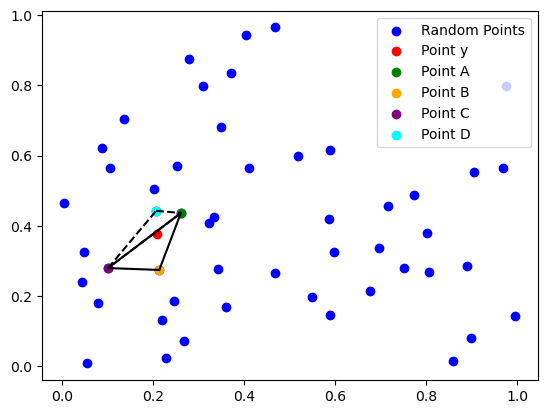

In [30]:
# Computing the barycentric coordinates
def barycentric_coordinates(A, B, C, y):
    denominator = (B[1] - C[1]) * (A[0] - C[0]) + (C[0] - B[0]) * (A[1] - C[1])
    
    r1 = ((B[1] - C[1]) * (y[0] - C[0]) + (C[0] - B[0]) * (y[1] - C[1])) / denominator
    r2 = ((C[1] - A[1]) * (y[0] - C[0]) + (A[0] - C[0]) * (y[1] - C[1])) / denominator
    r3 = 1 - r1 - r2
    
    return r1, r2, r3

def define_points(X, y):
    A = min(X, key=lambda x: np.sqrt((x[0] - y[0])**2 + (x[1] - y[1])**2) if x[0] > y[0] and x[1] > y[1] else float('inf'))
    B = min(X, key=lambda x: np.sqrt((x[0] - y[0])**2 + (x[1] - y[1])**2) if x[0] > y[0] and x[1] < y[1] else float('inf'))
    C = min(X, key=lambda x: np.sqrt((x[0] - y[0])**2 + (x[1] - y[1])**2) if x[0] < y[0] and x[1] < y[1] else float('inf'))
    D = min(X, key=lambda x: np.sqrt((x[0] - y[0])**2 + (x[1] - y[1])**2) if x[0] < y[0] and x[1] > y[1] else float('inf'))
    
    return A, B, C, D

# Checking if the point is inside the triangle
def is_point_in_triangle(A, B, C, y):
    r1, r2, r3 = barycentric_coordinates(A, B, C, y)
    return (0 <= r1 <= 1) and (0 <= r2 <= 1) and (0 <= r3 <= 1)

def algorithm(X, y):
    A, B, C, D = define_points(X, y)
    
    if any(np.isinf([A, B, C, D]).flatten()):
        return np.nan
    if is_point_in_triangle(A, B, C, y):
        return y
    if is_point_in_triangle(C, D, A, y):
        return y
    
    return np.nan



A, B, C, D = define_points(X, y)

result = algorithm(X, y)
result

# Plotting the points and triangles
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Random Points')
plt.scatter(y[0], y[1], color='red', label='Point y')
plt.scatter(A[0], A[1], color='green', label='Point A')
plt.scatter(B[0], B[1], color='orange', label='Point B')
plt.scatter(C[0], C[1], color='purple', label='Point C')
plt.scatter(D[0], D[1], color='cyan', label='Point D')


plt.plot([A[0], B[0]], [A[1], B[1]], 'k-')
plt.plot([B[0], C[0]], [B[1], C[1]], 'k-')
plt.plot([C[0], A[0]], [C[1], A[1]], 'k-')

plt.plot([C[0], D[0]], [C[1], D[1]], 'k--')
plt.plot([D[0], A[0]], [D[1], A[1]], 'k--')
plt.plot([A[0], C[0]], [A[1], C[1]], 'k--')

plt.legend()
plt.show()


**Question 2:** Compute the barycentric coordinates of the point $y$ with respect to the triangles $ABC$ and $CDA$. Which triangle is $y$ located inside?

In [31]:
# Compute barycentric coordinates of y with respect to triangle ABC and CDA
r1_ABC, r2_ABC, r3_ABC = barycentric_coordinates(A, B, C, y)
r1_CDA, r2_CDA, r3_CDA = barycentric_coordinates(C, D, A, y)

print(f"Barycentric coordinates with respect to ABC: r1={r1_ABC}, r2={r2_ABC}, r3={r3_ABC}")
print(f"Barycentric coordinates with respect to CDA: r1={r1_CDA}, r2={r2_CDA}, r3={r3_CDA}")

# Determining which triangle contains the point y
inside_ABC = is_point_in_triangle(A, B, C, y)
inside_CDA = is_point_in_triangle(C, D, A, y)

triangle_containing_y = "ABC" if inside_ABC else "CDA" if inside_CDA else "None"
print(f"Point y is located inside the triangle: {triangle_containing_y}")


Barycentric coordinates with respect to ABC: r1=0.6286263152916166, r2=0.06910145494351515, r3=0.3022722297648682
Barycentric coordinates with respect to CDA: r1=0.3682598757102867, r2=-0.13392661883334067, r3=0.765666743123054
Point y is located inside the triangle: ABC


Now consider the function:
$$
f(x_1,x_2) = x_1 \cdot x_2
$$

In [32]:
f = lambda x: x[0]*x[1]
F = np.array([f(x) for x in X])

**Question 3:** Compute the approximation of $f(y)$ using the full algorithm. Compare with the true value.

In [33]:
# The true value of f(y)
true_value = f(y)

# The function values at points A, B, and C
f_A = f(A)
f_B = f(B)
f_C = f(C)

# Approximating f(y)
approx_value = r1_ABC * f_A + r2_ABC * f_B + r3_ABC * f_C

true_value, approx_value


(0.0789565216259594, 0.08405201731052576)

We see that the true value and the approximated valuie are somewhat close to eachother

**Question 4:** Repeat question 3 for all points in the set $Y$.

In [34]:
Y = [(0.2,0.2),(0.8,0.2),(0.8,0.8),(0.5,0.5)]

In [35]:
# Computing the approximation for a single point y
def compute_approximation(y, A, B, C, D):
    true_value = f(y)
    
    # Determining which triangle containing y
    if is_point_in_triangle(A, B, C, y):
        r1, r2, r3 = barycentric_coordinates(A, B, C, y)
        f_A, f_B, f_C = f(A), f(B), f(C)
        approx_value = r1 * f_A + r2 * f_B + r3 * f_C
    elif is_point_in_triangle(C, D, A, y):
        r1, r2, r3 = barycentric_coordinates(C, D, A, y)
        f_C, f_D, f_A = f(C), f(D), f(A)
        approx_value = r1 * f_C + r2 * f_D + r3 * f_A
    else:
        approx_value = np.nan
    
    return true_value, approx_value

# True and approximate values for all points in Y
results = [compute_approximation(y, A, B, C, D) for y in Y]
results

[(0.04000000000000001, nan),
 (0.16000000000000003, nan),
 (0.6400000000000001, nan),
 (0.25, nan)]

None of these points are insde the triangle